In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
ruta = Path("data/REHAB/Rehab_exercise/d02_processed_data")

for npy in ruta.iterdir():
    try:
        sample = np.load(npy, allow_pickle=True)
        print(npy.name)
        print(sample.shape)
    except Exception as e:
        print(f"Error loading {npy.name}: {e}")


000_1.npy
(232, 880, 6)
000_2.npy
(232, 880, 6)
001_1.npy
(212, 880, 6)
001_2.npy
(212, 880, 6)
002_1.npy
(267, 880, 6)
002_2.npy
(267, 880, 6)
003_1.npy
(250, 880, 6)
003_2.npy
(250, 880, 6)
004_1.npy
(287, 880, 6)
004_2.npy
(287, 880, 6)
005_1.npy
(293, 880, 6)
005_2.npy
(293, 880, 6)
006_1.npy
(260, 880, 6)
006_2.npy
(260, 880, 6)
007_1.npy
(385, 880, 6)
007_2.npy
(385, 880, 6)
008_1.npy
(299, 880, 6)
008_2.npy
(299, 880, 6)
009_1.npy
(307, 880, 6)
009_2.npy
(307, 880, 6)
010_1.npy
(311, 880, 6)
010_2.npy
(311, 880, 6)
011_1.npy
(235, 880, 6)
011_2.npy
(235, 880, 6)
012_1.npy
(293, 880, 6)
012_2.npy
(293, 880, 6)
013_1.npy
(313, 880, 6)
013_2.npy
(313, 880, 6)
Error loading 014_1.npy: Failed to interpret file WindowsPath('data/REHAB/Rehab_exercise/d02_processed_data/014_1.npy') as a pickle
014_2.npy
(359, 880, 6)
015_1.npy
(313, 880, 6)
015_2.npy
(313, 880, 6)


014_1.npy esta danado :o

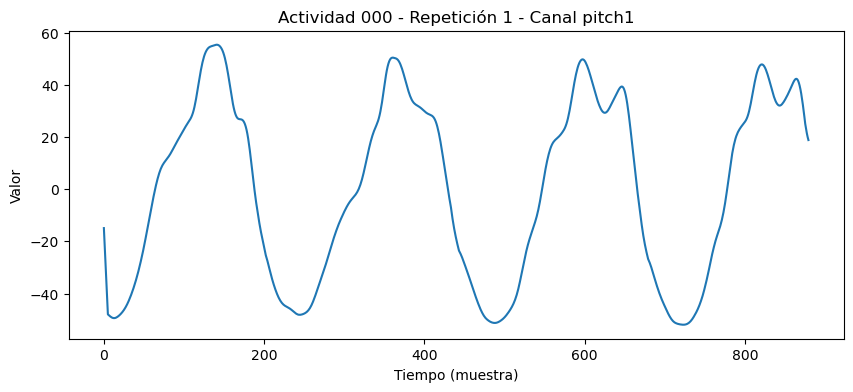

In [16]:
data = np.load("d02_processed_data/000_1.npy")

actividad = 0
repeticion = 0
canal = 0  # pitch1

x = data[repeticion, :, canal]

plt.figure(figsize=(10,4))
plt.plot(x)
plt.xlabel("Tiempo (muestra)")
plt.ylabel("Valor")
plt.title("Actividad 000 - Repetición 1 - Canal pitch1")
plt.show()

In [20]:
ruta = Path("d02_processed_data")

canales = [
    "pitch1",
    "yaw1",
    "roll1",
    "pitch2",
    "yaw2",
    "roll2"
]

# Buscar todos los archivos _1.npy excepto el dañado
archivos = sorted(
    archivo for archivo in ruta.glob("*_1.npy")
    if archivo.name != "014_1.npy"
)

print(f"Archivos válidos encontrados: {len(archivos)}")

for archivo in archivos:
    data = np.load(archivo)
    print(f"{archivo.name}: {data.shape}")

Archivos válidos encontrados: 15
000_1.npy: (232, 880, 6)
001_1.npy: (212, 880, 6)
002_1.npy: (267, 880, 6)
003_1.npy: (250, 880, 6)
004_1.npy: (287, 880, 6)
005_1.npy: (293, 880, 6)
006_1.npy: (260, 880, 6)
007_1.npy: (385, 880, 6)
008_1.npy: (299, 880, 6)
009_1.npy: (307, 880, 6)
010_1.npy: (311, 880, 6)
011_1.npy: (235, 880, 6)
012_1.npy: (293, 880, 6)
013_1.npy: (313, 880, 6)
015_1.npy: (313, 880, 6)


In [23]:
conteos = []
actividades_validas = []

for archivo in archivos:
    data = np.load(archivo)

    actividad = int(archivo.stem.split("_")[0])

    actividades_validas.append(actividad)
    conteos.append(data.shape[0])

tabla_conteos = pd.DataFrame({
    "Actividad": [f"{x:03d}" for x in actividades_validas],
    "Repeticiones": conteos
})

display(tabla_conteos)

,Actividad,Repeticiones
0,000,232
1,001,212
2,002,267
3,003,250
4,004,287
5,005,293
6,006,260
7,007,385
8,008,299
9,009,307


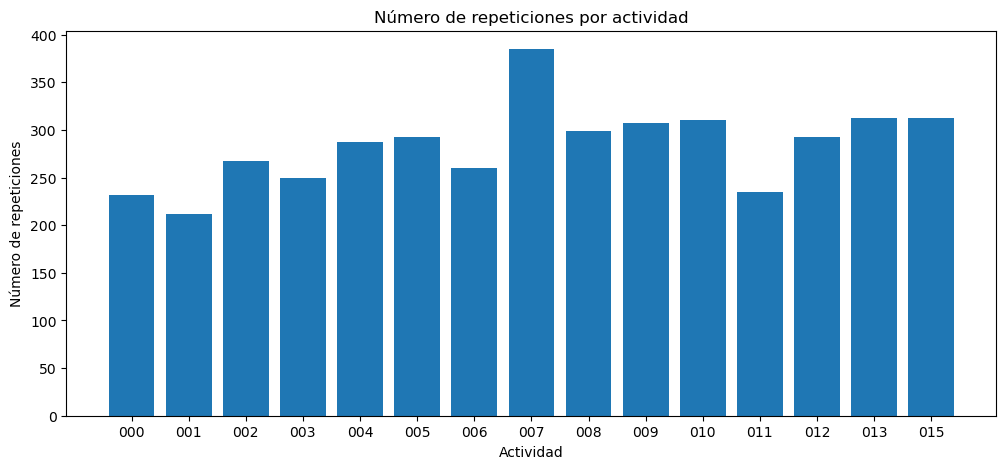

In [24]:
plt.figure(figsize=(12, 5))

plt.bar(
    [f"{x:03d}" for x in actividades_validas],
    conteos
)

plt.xlabel("Actividad")
plt.ylabel("Número de repeticiones")
plt.title("Número de repeticiones por actividad")

plt.show()

In [25]:
canal = 0

resultados = []

for archivo in archivos:

    actividad = int(archivo.stem.split("_")[0])
    data = np.load(archivo)

    # Concatenar todas las repeticiones y puntos temporales
    valores = data[:, :, canal].flatten()

    resultados.append({
        "Actividad": f"{actividad:03d}",
        "Media": np.mean(valores),
        "Mediana": np.median(valores)
    })

tabla_estadisticas = pd.DataFrame(resultados)

display(tabla_estadisticas)

,Actividad,Media,Mediana
0,000,-1.147114e-16,1.587262
1,001,1.675808e-17,0.000000
2,002,-8.709410e-17,1.092490
3,003,-5.270935e-17,-3.553140
4,004,1.260386e-17,0.000000
5,005,-2.204600e-19,0.000000
6,006,2.921672e-16,0.000000
7,007,2.114011e-17,-0.050467
8,008,-8.641444e-17,-3.178819
9,009,0.000000e+00,-1.969354


In [26]:
def comparar_actividades(actividad_1, actividad_2, canal=0, bins=50):

    archivo_1 = ruta / f"{actividad_1:03d}_1.npy"
    archivo_2 = ruta / f"{actividad_2:03d}_1.npy"

    # Verificar que los archivos existan
    if not archivo_1.exists():
        print(f"No existe el archivo de la actividad {actividad_1:03d}")
        return

    if not archivo_2.exists():
        print(f"No existe el archivo de la actividad {actividad_2:03d}")
        return

    data_1 = np.load(archivo_1)
    data_2 = np.load(archivo_2)

    valores_1 = data_1[:, :, canal].flatten()
    valores_2 = data_2[:, :, canal].flatten()

    media_1 = np.mean(valores_1)
    media_2 = np.mean(valores_2)

    plt.figure(figsize=(10, 5))

    plt.hist(
        valores_1,
        bins=bins,
        alpha=0.5,
        label=f"Actividad {actividad_1:03d}"
    )

    plt.hist(
        valores_2,
        bins=bins,
        alpha=0.5,
        label=f"Actividad {actividad_2:03d}"
    )

    plt.axvline(
        media_1,
        linestyle="--",
        linewidth=2,
        label=f"Media {actividad_1:03d} = {media_1:.2f}"
    )

    plt.axvline(
        media_2,
        linestyle="--",
        linewidth=2,
        label=f"Media {actividad_2:03d} = {media_2:.2f}"
    )

    plt.xlabel(canales[canal])
    plt.ylabel("Frecuencia")

    plt.title(
        f"Actividades {actividad_1:03d} vs {actividad_2:03d} "
        f"- Canal {canales[canal]}"
    )

    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

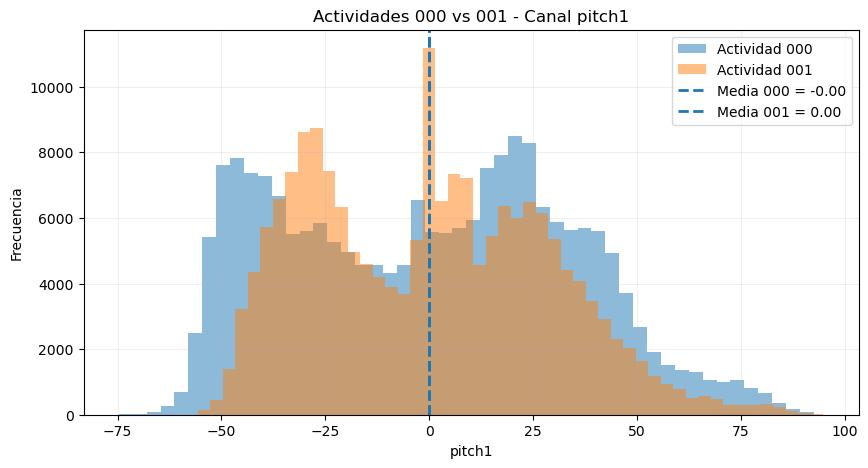

In [27]:
comparar_actividades(0, 1, canal=0, bins=50)

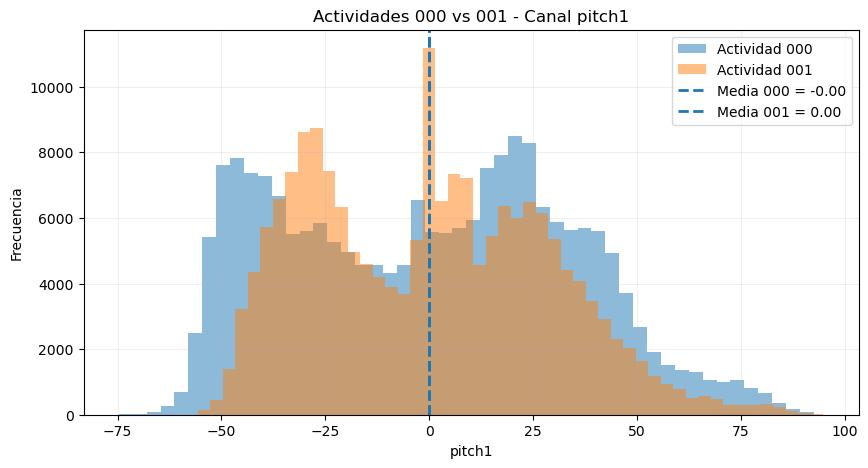

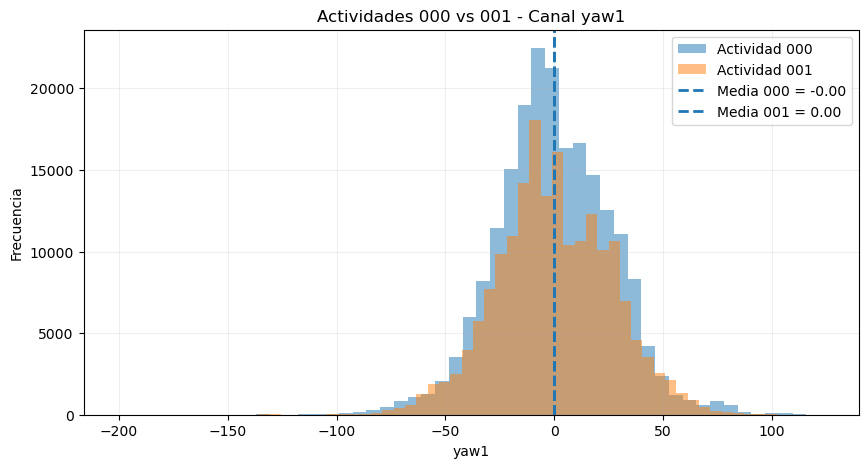

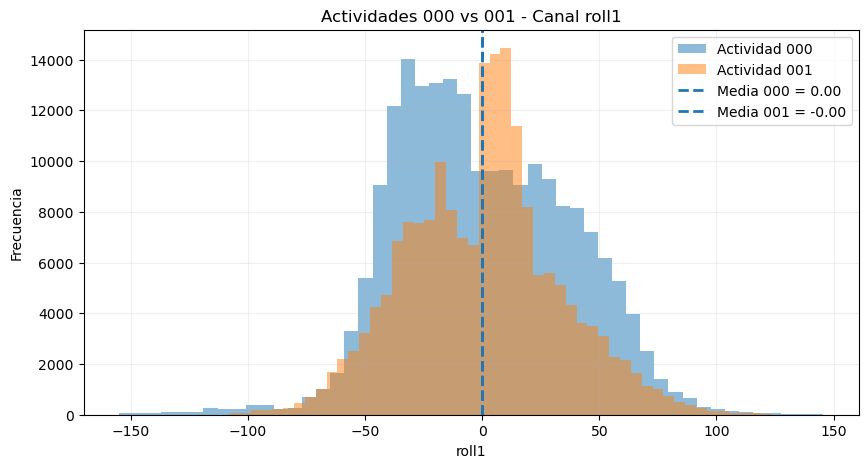

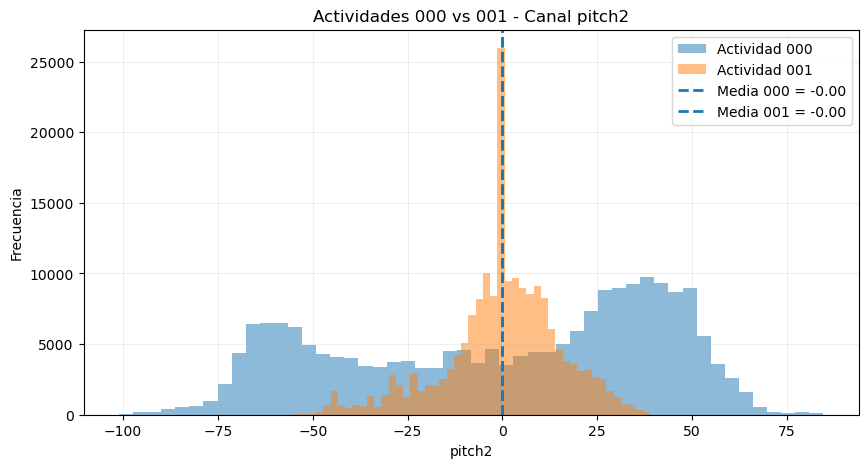

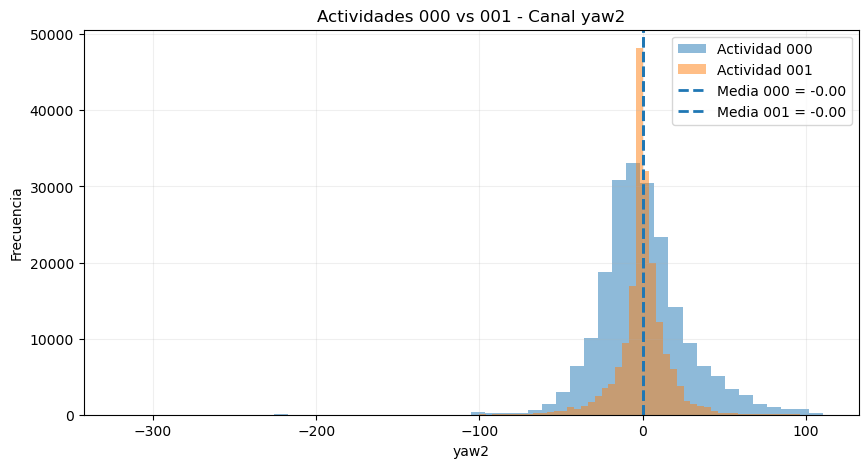

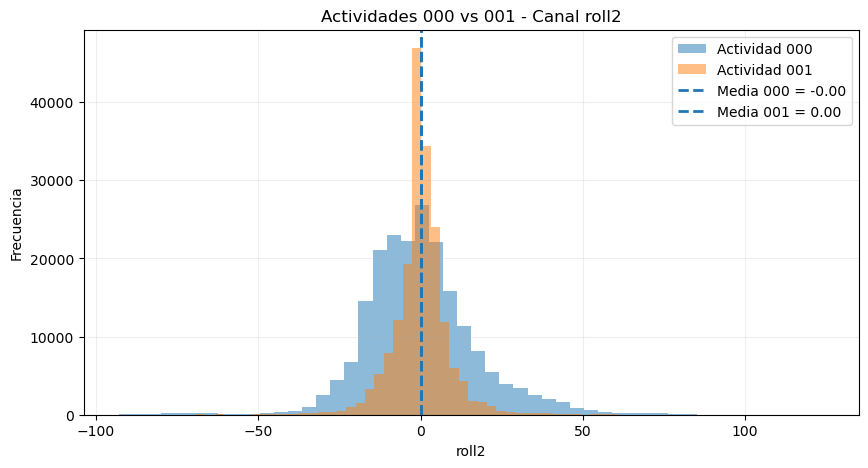

In [29]:
for canal in range(6):
    comparar_actividades(0, 1, canal=canal, bins=50)